<a href="https://colab.research.google.com/github/JoGabTasca/ML/blob/main/aula01_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning
## Livros aula:
- https://page-flip-vault.lovable.app/

In [ ]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo visual dos gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Suprimindo warnings desnecessários para manter a saída limpa
import warnings
warnings.filterwarnings('ignore')

print("Ambiente configurado com sucesso!")
print(f"Versão do pandas: {pd.__version__}")
print(f"Versão do numpy: {np.__version__}")

Ambiente configurado com sucesso!
Versão do pandas: 2.2.2
Versão do numpy: 2.0.2


## Carregamento dos dados


In [ ]:
# Carregando o dataset
# from sklearn.datasets import load_boston
url = "https://raw.githubusercontent.com/alvaroriz/book_ml_datasets/refs/heads/main/BostonHousing.csv"
df = pd.read_csv(url)

# Visualizando as primeiras linhas
print("Primeiras 5 linhas do dataset:")
df.head()

Primeiras 5 linhas do dataset:


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
# Informações básicas sobre o dataset
print(f"\nDimensões do dataset: {df.shape}")
print(f"Número de amostras: {df.shape[0]}")
print(f"Número de features: {df.shape[1] - 1}")  # -1 para excluir a variável alvo


Dimensões do dataset: (506, 14)
Número de amostras: 506
Número de features: 13


Variavel alvo - medv (valor mediano das casas em $1000

In [ ]:
# Dicionário de descrição das features
feature_descriptions = {
'crim': 'Taxa de criminalidade per capita por cidade',
'zn': 'Proporção de terrenos residenciais zonados para lotes acima de 25.000 pés²',
'indus': 'Proporção de acres de negócios não varejistas por cidade',
'chas': 'Variável dummy do Rio Charles (1 se o terreno faz fronteira com o rio; 0 caso contrário)',
'nox': 'Concentração de óxidos nítricos (partes por 10 milhões)',
'rm': 'Número médio de quartos por habitação',
'age': 'Proporção de unidades ocupadas pelos proprietários construídas antes de 1940',
'dis': 'Distâncias ponderadas para cinco centros de emprego de Boston',
'rad': 'Índice de acessibilidade a rodovias radiais',
'tax': 'Taxa de imposto sobre a propriedade de valor total por $10.000',
'ptratio': 'Razão aluno-professor por cidade',
'b': '1000(Bk - 0.63)² onde Bk é a proporção de negros por cidade',
'lstat': '% de status mais baixo da população',
'medv': 'Valor mediano das casas ocupadas pelos proprietários em $1000s (VARIÁVEL ALVO)'
}

print("\nDescrição das Features:")
for feature, description in feature_descriptions.items():
    print(f"  {feature:10s}: {description}")


Descrição das Features:
  crim      : Taxa de criminalidade per capita por cidade
  zn        : Proporção de terrenos residenciais zonados para lotes acima de 25.000 pés²
  indus     : Proporção de acres de negócios não varejistas por cidade
  chas      : Variável dummy do Rio Charles (1 se o terreno faz fronteira com o rio; 0 caso contrário)
  nox       : Concentração de óxidos nítricos (partes por 10 milhões)
  rm        : Número médio de quartos por habitação
  age       : Proporção de unidades ocupadas pelos proprietários construídas antes de 1940
  dis       : Distâncias ponderadas para cinco centros de emprego de Boston
  rad       : Índice de acessibilidade a rodovias radiais
  tax       : Taxa de imposto sobre a propriedade de valor total por $10.000
  ptratio   : Razão aluno-professor por cidade
  b         : 1000(Bk - 0.63)² onde Bk é a proporção de negros por cidade
  lstat     : % de status mais baixo da população
  medv      : Valor mediano das casas ocupadas pelos propri

In [ ]:
# Separando as features (X) da variável alvo (y)
from sklearn.model_selection import train_test_split

X = df.drop('medv', axis=1)
y = df['medv']

print("Estrutura dos dados:")
print(f"X (features): {X.shape}")
print(f"y (alvo): {y.shape}")

Estrutura dos dados:
X (features): (506, 13)
y (alvo): (506,)


In [ ]:
# A divisão estratégica: 80% para treino, 20% para teste

# random_state garante reprodutibilidade - essencial para ciência reprodutível
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% dos dados para teste
    random_state=42     # Semente para reprodutibilidade
)

# Verificando as dimensões dos conjuntos resultantes
print("\n" + "="*60)
print("DIVISÃO DOS DADOS CONCLUÍDA")
print("="*60)
print(f"Conjunto de TREINO:")
print(f"  X_train: {X_train.shape[0]} amostras, {X_train.shape[1]} features")
print(f"  y_train: {y_train.shape[0]} valores alvo")
print(f"\nConjunto de TESTE (SELADO):")
print(f"  X_test:  {X_test.shape[0]} amostras, {X_test.shape[1]} features")
print(f"  y_test:  {y_test.shape[0]} valores alvo")
print("="*60)


DIVISÃO DOS DADOS CONCLUÍDA
Conjunto de TREINO:
  X_train: 404 amostras, 13 features
  y_train: 404 valores alvo

Conjunto de TESTE (SELADO):
  X_test:  102 amostras, 13 features
  y_test:  102 valores alvo


In [ ]:
# Verificando se a divisão preservou a distribuição da variável alvo

print("\nVerificação da Representatividade da Divisão:")
print("-" * 60)
print(f"Estatísticas da variável alvo (medv) - Dataset Completo:")
print(f"  Média:   ${y.mean():.2f}k")
print(f"  Mediana: ${y.median():.2f}k")
print(f"  Desvio:  ${y.std():.2f}k")
print(f"  Mínimo:  ${y.min():.2f}k")
print(f"  Máximo:  ${y.max():.2f}k")

print(f"\nEstatísticas da variável alvo - Conjunto de TREINO:")
print(f"  Média:   ${y_train.mean():.2f}k")
print(f"  Mediana: ${y_train.median():.2f}k")
print(f"  Desvio:  ${y_train.std():.2f}k")

print(f"\nEstatísticas da variável alvo - Conjunto de TESTE:")
print(f"  Média:   ${y_test.mean():.2f}k")
print(f"  Mediana: ${y_test.median():.2f}k")
print(f"  Desvio:  ${y_test.std():.2f}k")


Verificação da Representatividade da Divisão:
------------------------------------------------------------
Estatísticas da variável alvo (medv) - Dataset Completo:
  Média:   $22.53k
  Mediana: $21.20k
  Desvio:  $9.20k
  Mínimo:  $5.00k
  Máximo:  $50.00k

Estatísticas da variável alvo - Conjunto de TREINO:
  Média:   $22.80k
  Mediana: $21.60k
  Desvio:  $9.33k

Estatísticas da variável alvo - Conjunto de TESTE:
  Média:   $21.49k
  Mediana: $20.15k
  Desvio:  $8.61k


## Plotagem dos dados

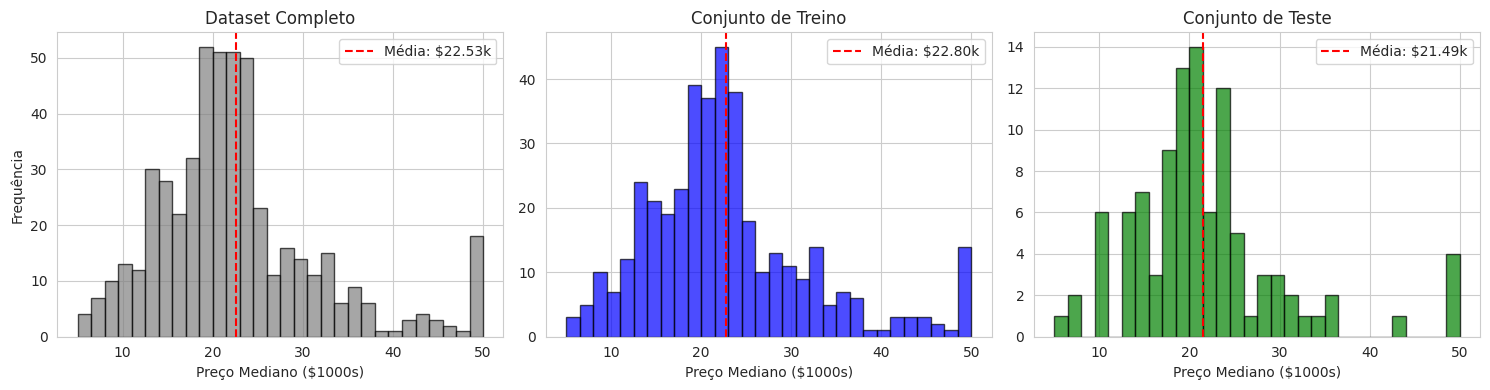


✓ Divisão concluída e verificada!
✓ O conjunto de teste está agora SELADO até o julgamento final.


In [ ]:
# Visualização da distribuição da variável alvo nos três conjuntos

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(y, bins=30, color='gray', alpha=0.7, edgecolor='black')
axes[0].set_title('Dataset Completo')
axes[0].set_xlabel('Preço Mediano ($1000s)')
axes[0].set_ylabel('Frequência')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Média: ${y.mean():.2f}k')
axes[0].legend()

axes[1].hist(y_train, bins=30, color='blue', alpha=0.7, edgecolor='black')
axes[1].set_title('Conjunto de Treino')
axes[1].set_xlabel('Preço Mediano ($1000s)')
axes[1].axvline(y_train.mean(), color='red', linestyle='--', label=f'Média: ${y_train.mean():.2f}k')
axes[1].legend()

axes[2].hist(y_test, bins=30, color='green', alpha=0.7, edgecolor='black')
axes[2].set_title('Conjunto de Teste')
axes[2].set_xlabel('Preço Mediano ($1000s)')
axes[2].axvline(y_test.mean(), color='red', linestyle='--', label=f'Média: ${y_test.mean():.2f}k')
axes[2].legend()

plt.tight_layout()
plt.show()